# Principal Component Analysis (PCA) for Dinemtionality Reduction

##Goal:
Implement Principal Component Analysis (PCA) from scratch on the MNIST dataset for dimensionality reduction and data visualization, as covered in Lecture 3 of Advanced Machine Learning (Deep Learning).

In [2]:
# =============================================
#     Dimensionality Reduction via PCA
# =============================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from scipy.io import loadmat
import os

##Load Dataset

In [3]:
# ----------------- Load Data -----------------
print("Loading MNIST...")
# Option 1: From openml (recommended)
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist.data.astype(np.float32)           # (70000, 784)
y = mnist.target.astype(int)

# Or load from your uploaded mnist_uint8.mat
# data = loadmat('mnist_uint8.mat')
# X = data['train_x'].astype(np.float32)
# y = data['train_y'].argmax(axis=1)

print(f"Data shape: {X.shape}")

Loading MNIST...
Data shape: (70000, 784)


##PCA Computation

- Implementation: Eigen decomposition of the covariance matrix using `np.linalg.eigh`
- Computed: Top 100 Principal Components
- Key Functions: Custom `compute_pca()` with proper sorting of eigenvalues/eigenvectors

In [4]:
# ----------------- Compute PCA -----------------
def compute_pca(X, n_components=None):
    # X should be N x D or D x N? We make it N x D
    if X.shape[0] < X.shape[1]:
        X = X.T

    # Mean center
    mean = np.mean(X, axis=0)
    X_centered = X - mean

    # Covariance matrix
    cov = np.cov(X_centered.T)                    # D x D

    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    if n_components is not None:
        eigenvectors = eigenvectors[:, :n_components]
        eigenvalues = eigenvalues[:n_components]

    return eigenvectors, eigenvalues, mean

In [5]:
# Compute PCA
evecs, evals, mean_vec = compute_pca(X, n_components=100)

print("PCA completed!")
print(f"Top 10 eigenvalues: {evals[:10]}")

PCA completed!
Top 10 eigenvalues: [334294.0613682  245433.42713124 210930.35436672 185337.35627237
 167691.57194164 147670.2960727  112445.13869732  99115.38341703
  94612.53835173  80335.95725932]


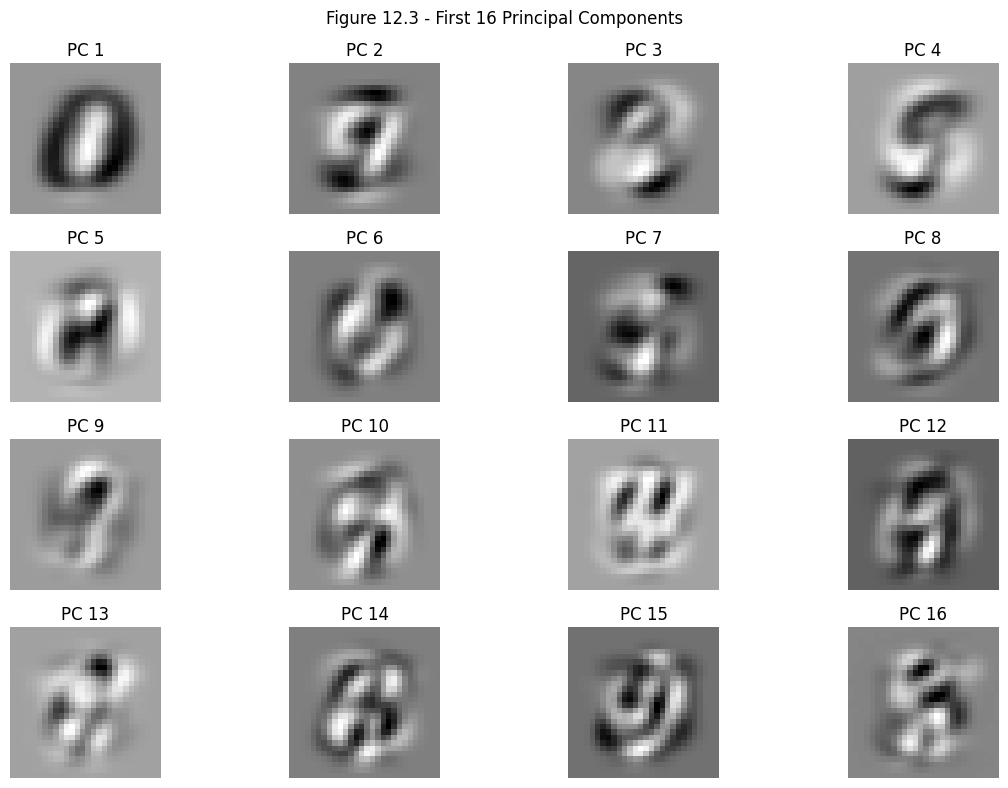

In [6]:
# ----------------- Figures -----------------

# Figure 12.3: First 16 Principal Components
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = evecs[:, i].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'PC {i+1}')
plt.suptitle("Figure 12.3 - First 16 Principal Components")
plt.tight_layout()
plt.savefig('fig_12_3.png', dpi=200, bbox_inches='tight')
plt.show()

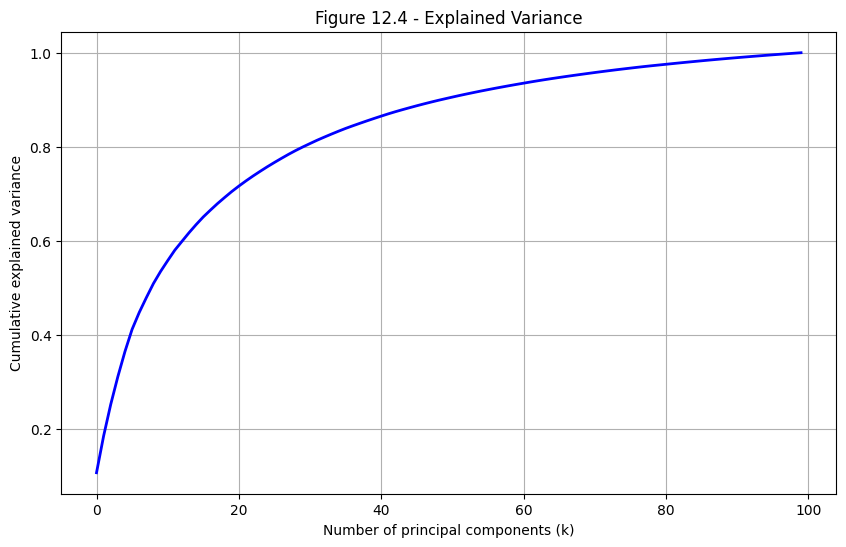

In [7]:
# Figure 12.4: Explained Variance
plt.figure(figsize=(10, 6))
cum_var = np.cumsum(evals) / np.sum(evals)
plt.plot(cum_var[:100], 'b-', linewidth=2)
plt.xlabel('Number of principal components (k)')
plt.ylabel('Cumulative explained variance')
plt.title('Figure 12.4 - Explained Variance')
plt.grid(True)
plt.savefig('fig_12_4.png', dpi=200, bbox_inches='tight')
plt.show()

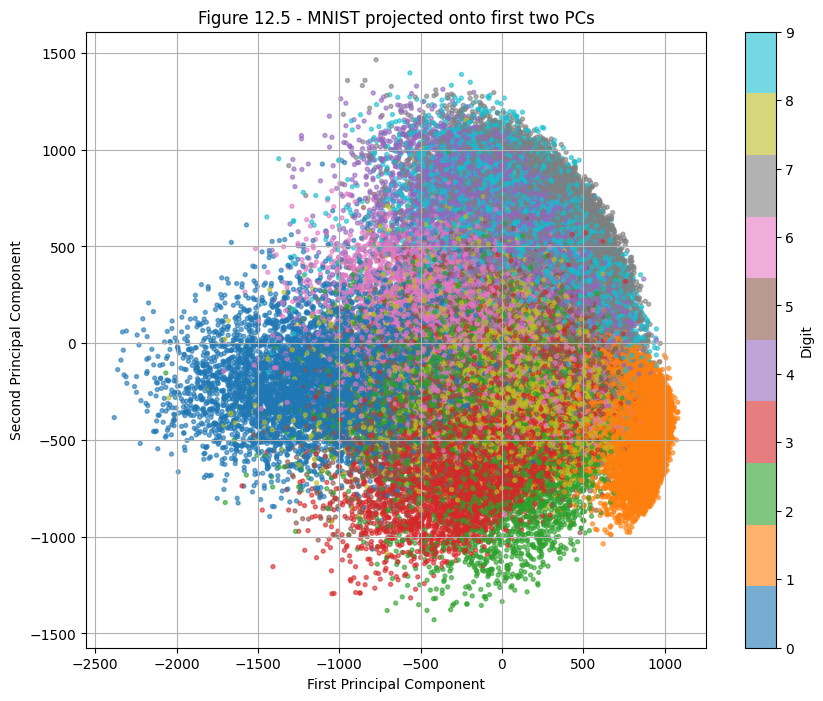

In [8]:
# Figure 12.5: Projection onto first 2 PCs
proj = (X - mean_vec) @ evecs[:, :2]

plt.figure(figsize=(10, 8))
scatter = plt.scatter(proj[:,0], proj[:,1], c=y, cmap='tab10', alpha=0.6, s=8)
plt.colorbar(scatter, label='Digit')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('Figure 12.5 - MNIST projected onto first two PCs')
plt.grid(True)
plt.savefig('fig_12_5.png', dpi=200, bbox_inches='tight')
plt.show()

In [9]:
# ----------------- Report Stats -----------------
print("\n=== Results ===")
print(f"Variance explained by top 50 PCs : {cum_var[49]*100:.2f}%")
print(f"Variance explained by top 100 PCs: {cum_var[99]*100:.2f}%")

# Save for submission
print("\nAll figures saved: fig_12_3.png, fig_12_4.png, fig_12_5.png")


=== Results ===
Variance explained by top 50 PCs : 90.21%
Variance explained by top 100 PCs: 100.00%

All figures saved: fig_12_3.png, fig_12_4.png, fig_12_5.png


## Results & Observations

- Top 50 Principal Components explain 90% of total variance
- Top 100 Principal Components explain 100% of total variance
- The first few principal components capture the most significant variations in handwriting styles. Early PCs capture global stroke patterns and digit shapes.
- Cumulative explained variance plot shows diminishing returns after ~50–100 components. Later PCs capture finer details and variations (e.g., loops, slants).


## Key Learnings

- PCA is an effective unsupervised technique for dimensionality reduction, feature extraction, and data visualization.
- Eigenvectors of the covariance matrix represent directions of maximum variance.
- Linear methods like PCA have limitations in capturing highly non-linear manifolds present in handwritten digits.

##Limitations

- PCA is a linear technique and may not capture complex non-linear relationships.
- Sensitive to scaling (though MNIST pixels are naturally in similar range).
- Computationally expensive for very high-dimensional data without optimizations.